In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error




In [2]:
df = pd.read_csv('student_placement_prediction_dataset_2026.csv')

In [3]:
df.head()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


In [4]:
df.tail()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
99995,99996,21,Male,7.97,Mechanical,Tier 2,0,3,5,71.483407,...,57.738311,75.471631,0,54.399022,66.446410,Yes,8.0,4.3,Placed,14.54
99996,99997,18,Female,7.79,CSE,Tier 1,1,1,2,78.960574,...,80.076688,77.286948,1,33.692154,69.025632,Yes,4.4,3.1,Not Placed,0.00
99997,99998,20,Female,6.71,IT,Tier 2,2,4,4,66.691775,...,70.797752,93.115933,0,64.989215,32.733645,Yes,7.6,2.9,Placed,13.45
99998,99999,19,Female,7.21,CSE,Tier 2,2,3,0,67.214893,...,68.182555,71.306355,1,72.478779,32.205517,No,4.9,2.8,Not Placed,0.00
99999,100000,22,Female,8.58,ECE,Tier 3,1,3,2,92.146277,...,77.864288,89.919640,0,48.363818,21.166444,Yes,6.5,2.9,Placed,14.43


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  object 
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  object 
 5   college_tier               100000 non-null  object 
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100

In [6]:
df.describe()

,student_id,age,cgpa,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,...,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,sleep_hours,study_hours_per_day,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,21.005740,7.496890,1.50223,3.001860,2.005150,69.825326,64.988108,67.960744,65.931696,...,4.005160,524.559110,69.989411,84.730169,0.497590,59.894049,54.937526,6.983319,3.523124,7.252106
std,28867.657797,1.999562,0.992834,1.22528,1.731764,1.416553,14.694618,14.844093,13.846636,14.826790,...,2.004897,274.993479,11.937257,9.416075,0.708434,19.549666,19.781197,1.468113,1.471248,6.735132
min,1.000000,18.000000,4.500000,0.00000,0.000000,0.000000,20.000000,20.000000,20.000000,20.000000,...,0.000000,50.000000,20.000000,50.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000
25%,25000.750000,19.000000,6.820000,1.00000,2.000000,1.000000,59.807945,54.894600,58.587535,55.940547,...,3.000000,287.000000,61.973172,78.325833,0.000000,46.538590,41.432390,6.000000,2.500000,0.000000
50%,50000.500000,21.000000,7.500000,1.00000,3.000000,2.000000,70.006250,65.011394,67.973221,66.003829,...,4.000000,523.000000,70.026665,85.018828,0.000000,60.079021,55.076210,7.000000,3.500000,11.100000
75%,75000.250000,23.000000,8.180000,2.00000,4.000000,3.000000,80.058762,75.079266,77.503749,76.113705,...,5.000000,764.000000,78.122083,91.782511,1.000000,73.549567,68.530115,8.000000,4.500000,13.470000
max,100000.000000,24.000000,10.000000,8.00000,13.000000,11.000000,100.000000,100.000000,100.000000,100.000000,...,16.000000,999.000000,100.000000,100.000000,6.000000,100.000000,100.000000,10.000000,10.000000,20.440000


In [7]:
df.columns

Index(['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier',
       'internships_count', 'projects_count', 'certifications_count',
       'coding_skill_score', 'aptitude_score', 'communication_skill_score',
       'logical_reasoning_score', 'hackathons_participated', 'github_repos',
       'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
       'backlogs', 'extracurricular_score', 'leadership_score',
       'volunteer_experience', 'sleep_hours', 'study_hours_per_day',
       'placement_status', 'salary_package_lpa'],
      dtype='object')

In [8]:
df.isnull().sum()

student_id                   0
age                          0
gender                       0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
coding_skill_score           0
aptitude_score               0
communication_skill_score    0
logical_reasoning_score      0
hackathons_participated      0
github_repos                 0
linkedin_connections         0
mock_interview_score         0
attendance_percentage        0
backlogs                     0
extracurricular_score        0
leadership_score             0
volunteer_experience         0
sleep_hours                  0
study_hours_per_day          0
placement_status             0
salary_package_lpa           0
dtype: int64

In [9]:
df.isna().sum()

student_id                   0
age                          0
gender                       0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
coding_skill_score           0
aptitude_score               0
communication_skill_score    0
logical_reasoning_score      0
hackathons_participated      0
github_repos                 0
linkedin_connections         0
mock_interview_score         0
attendance_percentage        0
backlogs                     0
extracurricular_score        0
leadership_score             0
volunteer_experience         0
sleep_hours                  0
study_hours_per_day          0
placement_status             0
salary_package_lpa           0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.drop('student_id', axis=1, inplace=True)

age


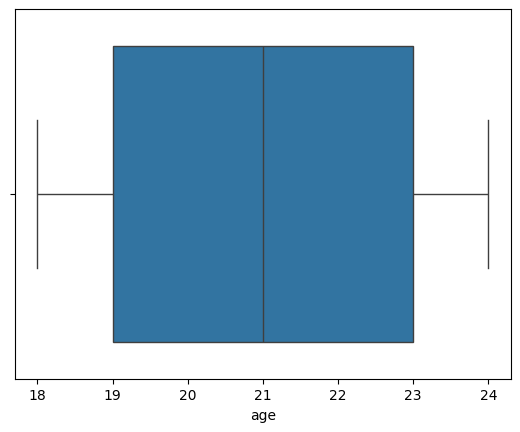

gender


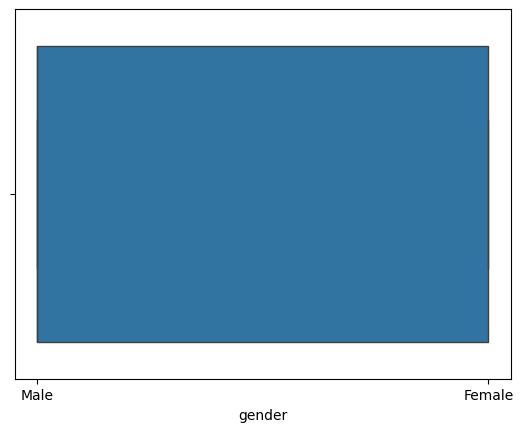

cgpa


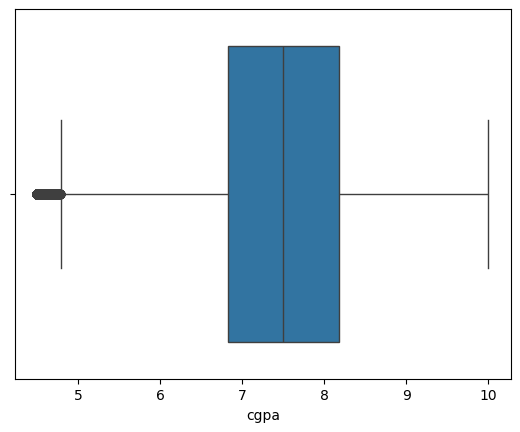

branch


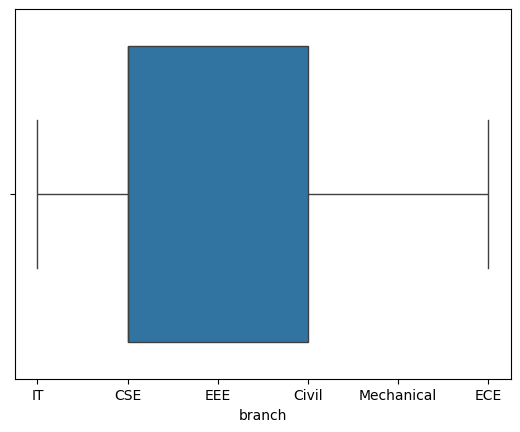

college_tier


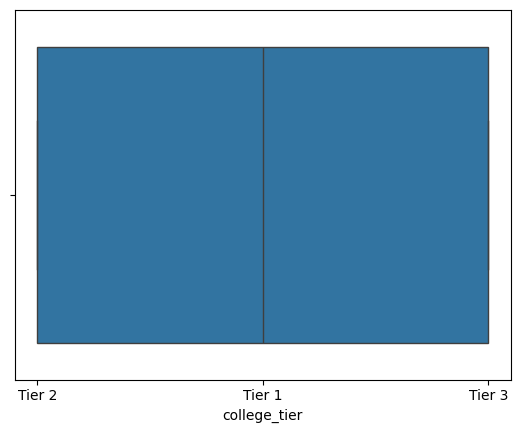

internships_count


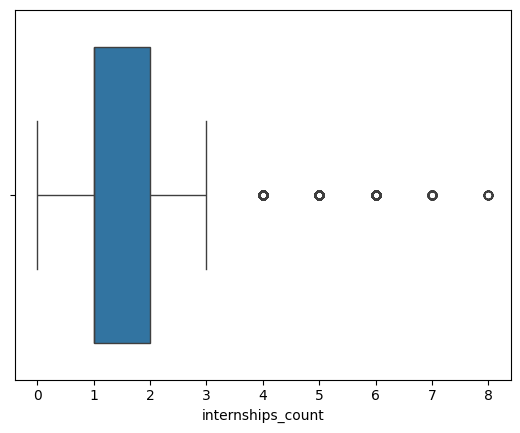

projects_count


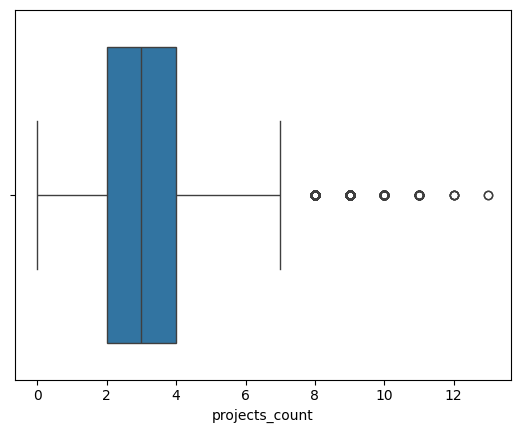

certifications_count


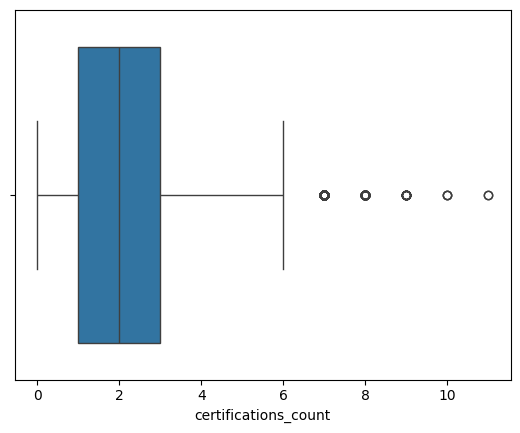

coding_skill_score


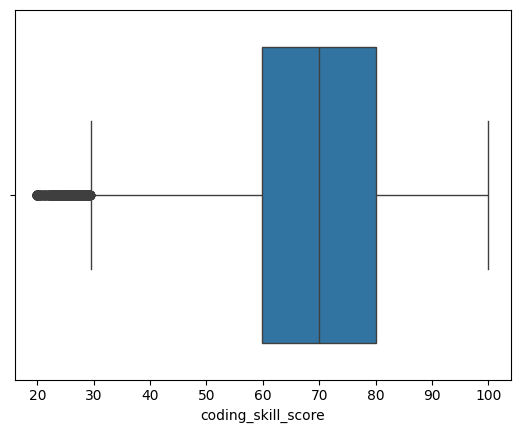

aptitude_score


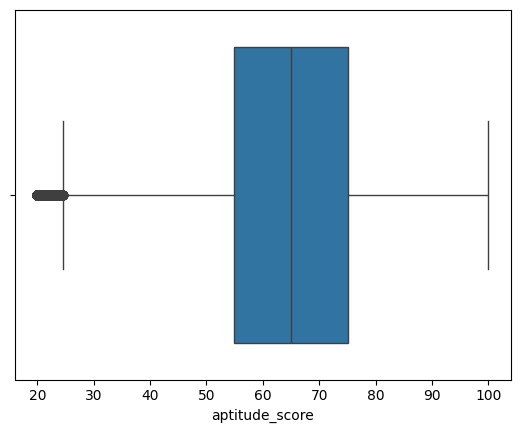

communication_skill_score


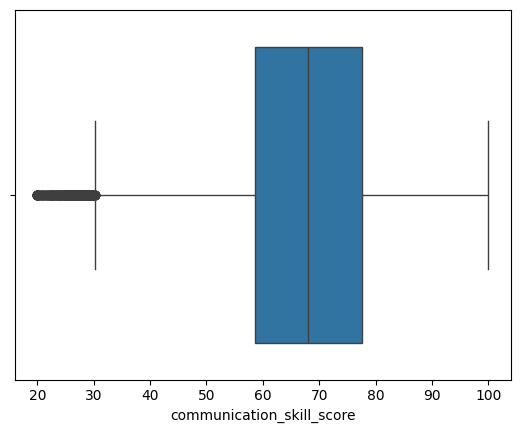

logical_reasoning_score


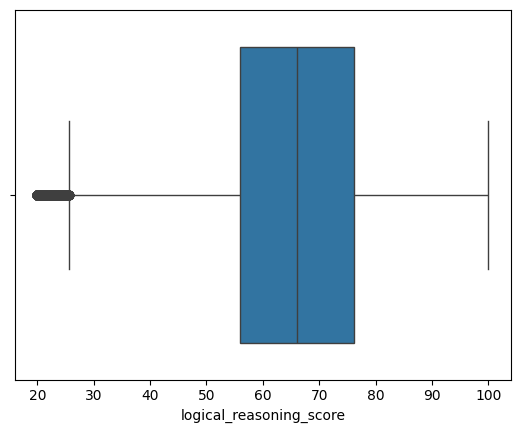

hackathons_participated


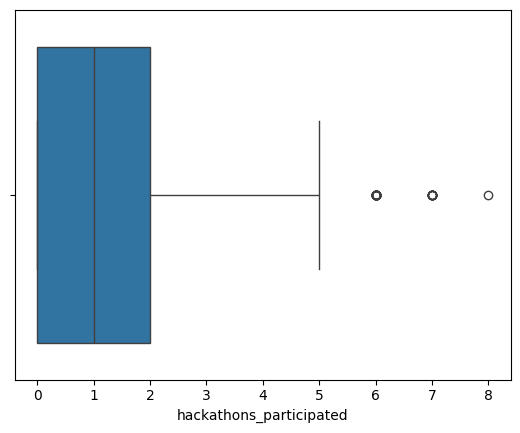

github_repos


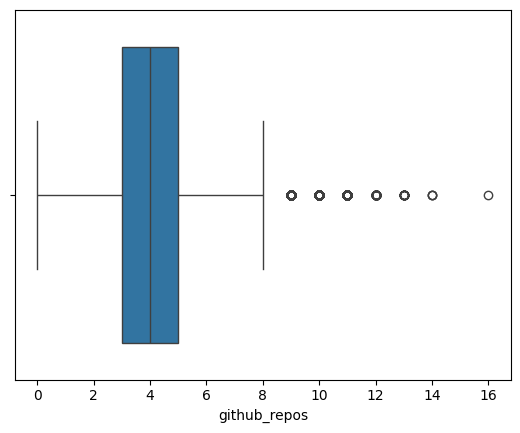

linkedin_connections


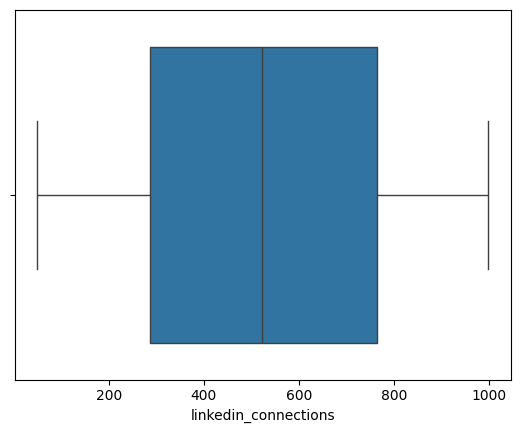

mock_interview_score


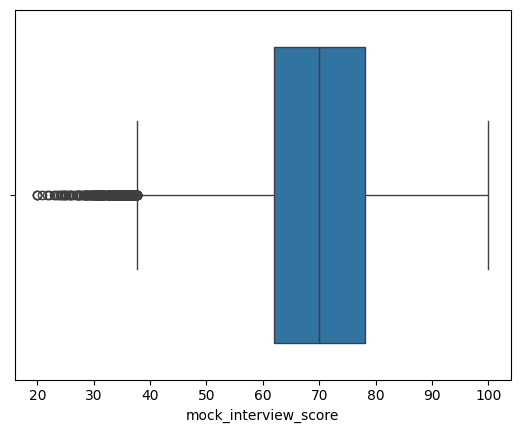

attendance_percentage


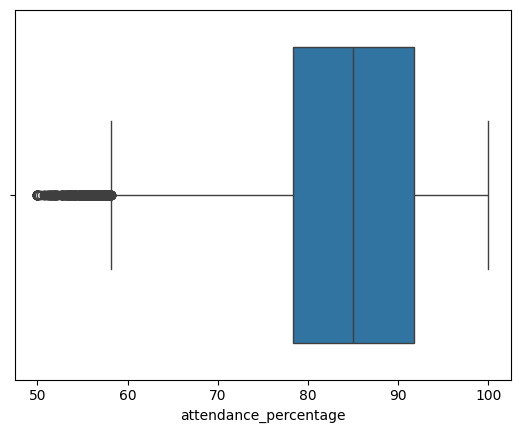

backlogs


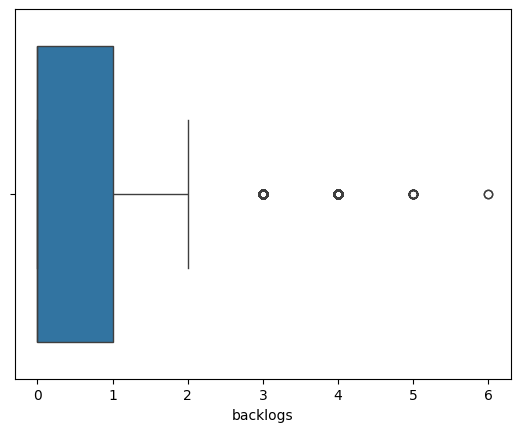

extracurricular_score


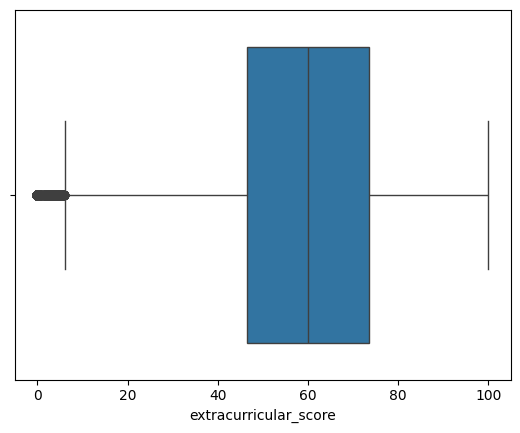

leadership_score


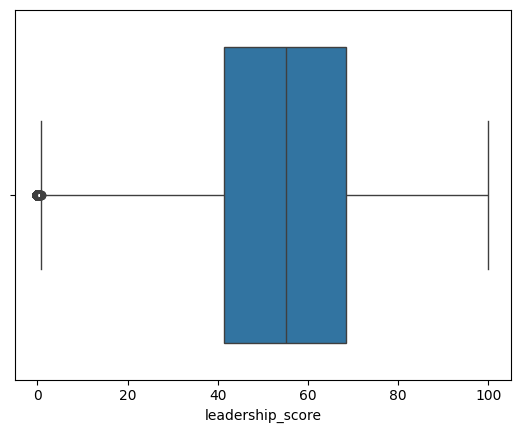

volunteer_experience


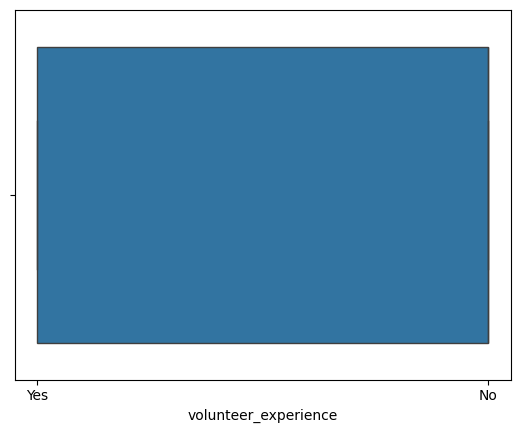

sleep_hours


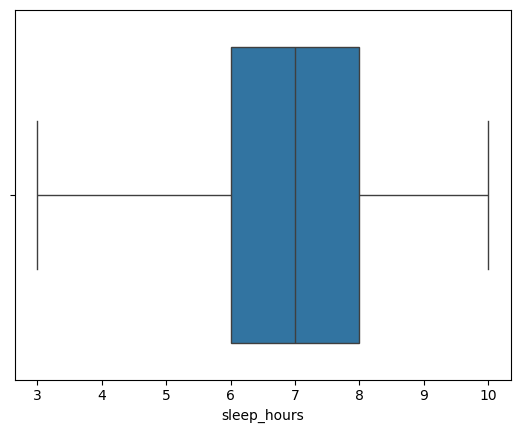

study_hours_per_day


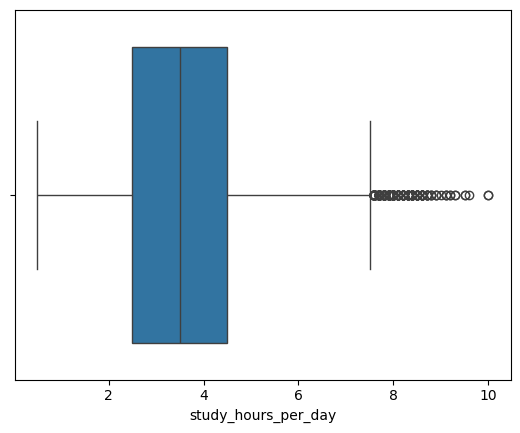

placement_status


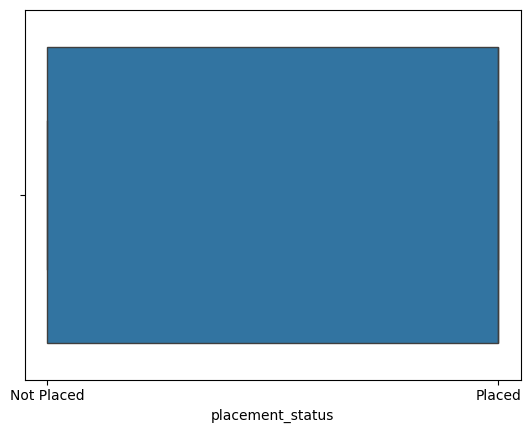

salary_package_lpa


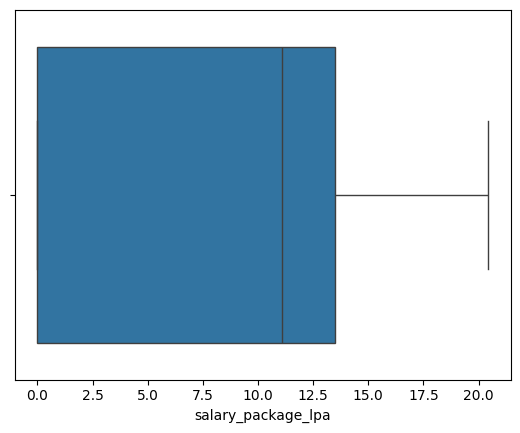

In [12]:
for col_name in df:
    print(col_name)
    sns.boxplot(df,x=col_name)
    plt.show()

In [13]:
df.columns

Index(['age', 'gender', 'cgpa', 'branch', 'college_tier', 'internships_count',
       'projects_count', 'certifications_count', 'coding_skill_score',
       'aptitude_score', 'communication_skill_score',
       'logical_reasoning_score', 'hackathons_participated', 'github_repos',
       'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
       'backlogs', 'extracurricular_score', 'leadership_score',
       'volunteer_experience', 'sleep_hours', 'study_hours_per_day',
       'placement_status', 'salary_package_lpa'],
      dtype='object')

In [14]:
# df.drop(['attendance_percentage' , 'extracurricular_score' , 'leadership_score', 'volunteer_experience', 'sleep_hours' , 'study_hours_per_day'],axis=1,inplace=True)

In [15]:
df.columns

Index(['age', 'gender', 'cgpa', 'branch', 'college_tier', 'internships_count',
       'projects_count', 'certifications_count', 'coding_skill_score',
       'aptitude_score', 'communication_skill_score',
       'logical_reasoning_score', 'hackathons_participated', 'github_repos',
       'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
       'backlogs', 'extracurricular_score', 'leadership_score',
       'volunteer_experience', 'sleep_hours', 'study_hours_per_day',
       'placement_status', 'salary_package_lpa'],
      dtype='object')

In [16]:
df.drop('placement_status',axis=1,inplace=True)

In [17]:
df = df.drop(df[df['salary_package_lpa'] == 0].index)

In [18]:
(df['salary_package_lpa']==0).sum()

np.int64(0)

In [19]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54459 entries, 2 to 99999
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        54459 non-null  int64  
 1   gender                     54459 non-null  object 
 2   cgpa                       54459 non-null  float64
 3   branch                     54459 non-null  object 
 4   college_tier               54459 non-null  object 
 5   internships_count          54459 non-null  int64  
 6   projects_count             54459 non-null  int64  
 7   certifications_count       54459 non-null  int64  
 8   coding_skill_score         54459 non-null  float64
 9   aptitude_score             54459 non-null  float64
 10  communication_skill_score  54459 non-null  float64
 11  logical_reasoning_score    54459 non-null  float64
 12  hackathons_participated    54459 non-null  int64  
 13  github_repos               54459 non-null  int64  


In [21]:
cate_columns = ['branch','gender','college_tier', 'volunteer_experience']
for col in cate_columns:
    df[col] = le.fit_transform(df[col])
    

In [22]:
df

,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,...,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,salary_package_lpa
2,22,0,8.60,3,0,0,1,1,49.177184,48.658753,...,568,87.396911,74.153265,0,63.329294,43.708803,0,8.8,5.9,11.99
4,20,0,8.43,4,2,1,4,3,65.018573,61.274985,...,833,74.489201,79.120749,1,0.000000,67.268893,0,8.7,3.4,12.16
5,22,1,7.44,0,1,1,5,1,49.758865,45.252593,...,77,66.138578,82.038139,0,54.150818,69.210022,0,9.1,3.4,11.78
8,19,1,8.52,5,1,2,5,0,100.000000,93.987115,...,269,64.035703,89.884948,0,68.598878,42.647145,0,8.5,4.2,16.33
9,20,0,8.07,1,1,2,2,2,93.421972,71.379374,...,747,72.217117,88.901107,0,86.199176,1.371853,0,5.9,4.5,16.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99989,20,1,7.75,0,1,3,3,1,55.516358,34.593404,...,144,61.817704,100.000000,1,55.177100,49.893938,0,8.9,5.0,14.93
99991,23,0,8.10,1,1,2,5,4,81.775079,57.842082,...,959,80.204330,72.705861,1,42.276988,48.038799,1,6.8,3.2,15.67
99995,21,1,7.97,5,1,0,3,5,71.483407,56.904150,...,495,57.738311,75.471631,0,54.399022,66.446410,1,8.0,4.3,14.54
99997,20,0,6.71,4,1,2,4,4,66.691775,48.725390,...,272,70.797752,93.115933,0,64.989215,32.733645,1,7.6,2.9,13.45


In [23]:
x = df.drop('salary_package_lpa',axis=1)
y = df['salary_package_lpa']

In [24]:
x_train, x_test,y_train, y_test = train_test_split(x,y,test_size=0.2)

In [25]:
models = {
    'linear regression' : LinearRegression(),
    'ridge' : Ridge(),
    'lasso' : Lasso(),
    'elasticnet' : ElasticNet(),
    'decision tree' : DecisionTreeRegressor(),
    'random forest' : RandomForestRegressor(),
    'SVR' : SVR(),
    'Kneighbor' : KNeighborsRegressor(),
    'XGB' : XGBRegressor
}

In [28]:
results = {}
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    r2 = r2_score(y_test,y_pred)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    mae = mean_absolute_error(y_test,y_pred)
    results[name] = {
        'R2 Score' : r2,
        'RMSE' : rmse,
        'MAE' : mae
    }
    

In [35]:
import pandas as pd

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by='R2 Score', ascending=False)

print(results_df)

                   R2 Score      RMSE       MAE
ridge              0.610425  0.995338  0.795504
linear regression  0.610425  0.995338  0.795504
random forest      0.587233  1.024537  0.819523
XGB                0.581910  1.031122  0.824989
elasticnet         0.386014  1.249551  1.000116
SVR                0.293880  1.340029  1.072099
lasso              0.205330  1.421570  1.137768
decision tree      0.158144  1.463167  1.173165
Kneighbor          0.049912  1.554379  1.241535


In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

lr_params = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

lr_grid = GridSearchCV(
    LinearRegression(),
    lr_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

lr_grid.fit(x_train, y_train)

best_lr = lr_grid.best_estimator_

print("Best Linear Params:", lr_grid.best_params_)

Best Linear Params: {'fit_intercept': True, 'positive': True}


In [39]:
#from sklearn.ensemble import RandomForestRegressor

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(x_train, y_train)

best_rf = rf_grid.best_estimator_

print("Best RF Params:", rf_grid.best_params_)

Best RF Params: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
